In [2]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_loss

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Increase font sizes for better visibility
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

In [3]:
def load_plot(selected_group, experiments, common_args, loader, x_lim):
    results = {}
    for label in selected_group:
        if label not in experiments: continue
        algo_name, kwargs = experiments[label]
        data = loader.load(algo_name, **{**common_args, **kwargs}, specific_run=0)
        if data: results[label] = data

    if results:
        plot_results(results, x_lim, metric="acc", title=f"Test Accuracy on {common_args['dataset']} ({common_args['partition']})")
        # plot_loss(results, title=f"Training Loss on {common_args['dataset']} ({common_args['partition']})")
    else:
        print("\n[Error] No results loaded. Check the warnings above for path/parameter mismatches.")

In [4]:
loader = ResultLoader("../results")
experiments = {
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),
    "FedPLN": ("fedpln", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "har": 0, "fixed_proto": 0, "init_emb": 0}),
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1, "lambda_mcl": 0.01, "lambda_cc": 1.0}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1}),

    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),
    "FedProto": ("fedproto", {"mu": 1.0}),
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1, "ala_threshold": 0.1, "num_pre_loss": 10}),
    "FedTGP": ("fedtgp", {"lamda_": 10.0, "server_epochs": 10, "server_lr": 0.01, "margin_threshold": 1.0}),
    "LG-FedAvg": ("lgfedavg", {}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),
    "ProxyFL": ("proxyfl", {"mu": 1.0, "adj_type": "ring"}),
    "Local": ("local", {}),
}
global_algos = ["FedAvg", "FedProx", "Scaffold", "FedDyn", "FedPLN", "FedProc", "FedFM", "MOON", "FedLSA"]
personalized_algos = ["FedPer", "FedRep", "FedProto", "FedALA", "FedTGP", "LG-FedAvg", "FedKD", "FML", "ProxyFL", "FedSA", "Local"]

In [24]:
loader.algo_patterns["fedtgp1"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}"
loader.algo_patterns["fedtgp2"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}"
loader.algo_patterns["fedtgp3"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}"
loader.algo_patterns["fedtgp4"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}"
loader.algo_patterns["fedtgp5"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}"

common_args = {"dataset": "cifar10", "partition": "dirichlet", "num_clients": 10, "epochs": 2, "batch_size": 64, "lr": 0.01, "alpha": 0.1, "n_class": 2}
experiments["FedTGP1"] = ("fedtgp1", {"epochs": 1, "lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})
experiments["FedTGP2"] = ("fedtgp2", {"epochs": 1, "lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})
experiments["FedTGP3"] = ("fedtgp3", {"epochs": 1, "lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})
experiments["FedTGP4"] = ("fedtgp4", {"epochs": 1, "lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})
experiments["FedTGP5"] = ("fedtgp5", {"epochs": 1, "lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
FedALA               |         87.1523 |         84.9955
FedTGP-Model         |         85.0855 |         84.6235
FedTGP-Proto         |         84.9562 |         83.3485
FedTGP1-Model        |         85.6981 |         85.3315
FedTGP1-Proto        |         86.2356 |         85.6942
FedTGP2-Model        |         86.1309 |         85.5401
FedTGP2-Proto        |         86.5457 |         86.0085
FedTGP3-Model        |         85.7484 |         85.4662
FedTGP3-Proto        |         85.9816 |         85.6995
FedTGP5-Model        |         86.2194 |         85.9929
FedTGP5-Proto        |         86.4469 |         86.1614
-----------------------------------------------------------------


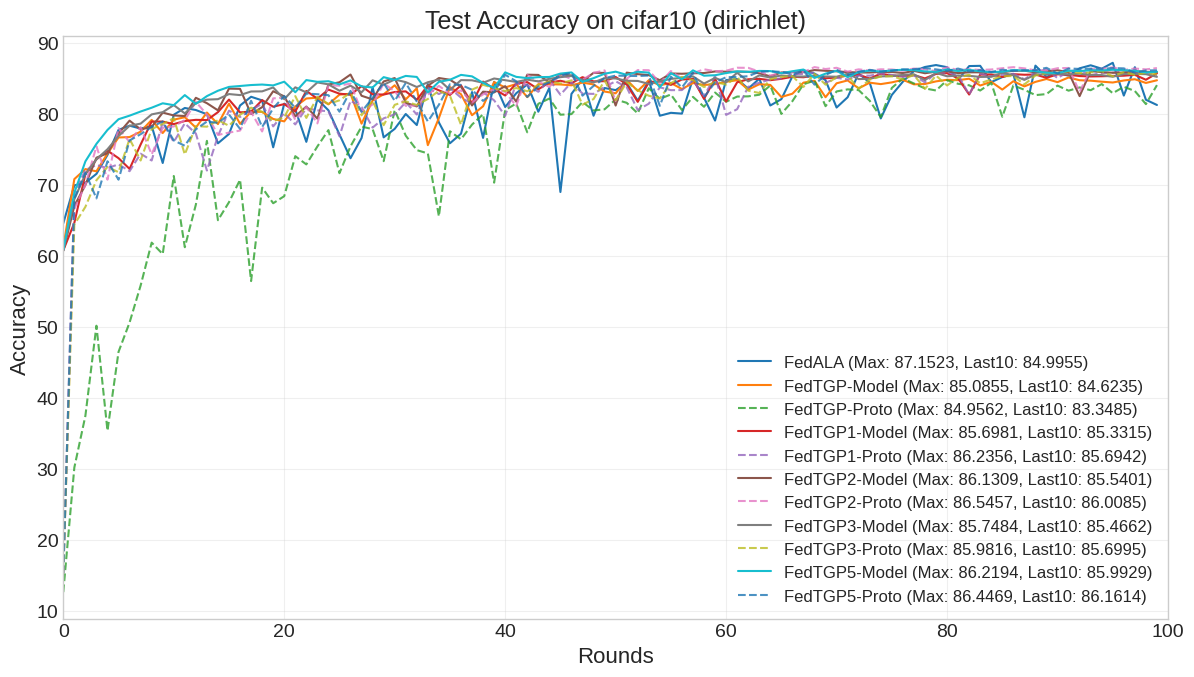

In [44]:
selected_group = personalized_algos.copy()
for algo in ['FedALA', 'FedPer', 'FedRep']:
    if algo in selected_group:
        selected_group.remove(algo)

selected_group = ['FedALA', 'FedTGP']
selected_group.extend(['FedTGP1', 'FedTGP2', 'FedTGP3', 'FedTGP5'])

load_plot(selected_group, experiments, common_args, loader, 100)